<a href="https://colab.research.google.com/github/animeshpthk07/microfinance-loan-delinquency-prediction/blob/main/notebooks/microfinance_credit_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Microfinance Dataset Ready! Total Records: 2500 | Delinquency Cases: 500

🧪 SCENARIO CHECKS (Test Cases for Decision Support)

📌 Scenario: High Risk Applicant
   Probability: 96.3%
   Tier:        HIGH RISK (Manual Intervention Required)
   Action:      Freeze automated disbursement; assign field officer for doorstep audit.
   Reason Codes: Frequent past late payments (4 in last 12M), High Debt-to-Income ratio (58.0%), Low credit score (480), Multiple active obligations (4 loans)

📌 Scenario: Low Risk Applicant
   Probability: 0.0%
   Tier:        LOW RISK (Fast-Track)
   Action:      Approve for automated loan disbursement.
   Reason Codes: Strong repayment history and balanced debt profile


/tmp/ipykernel_693/2204850925.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette='viridis')


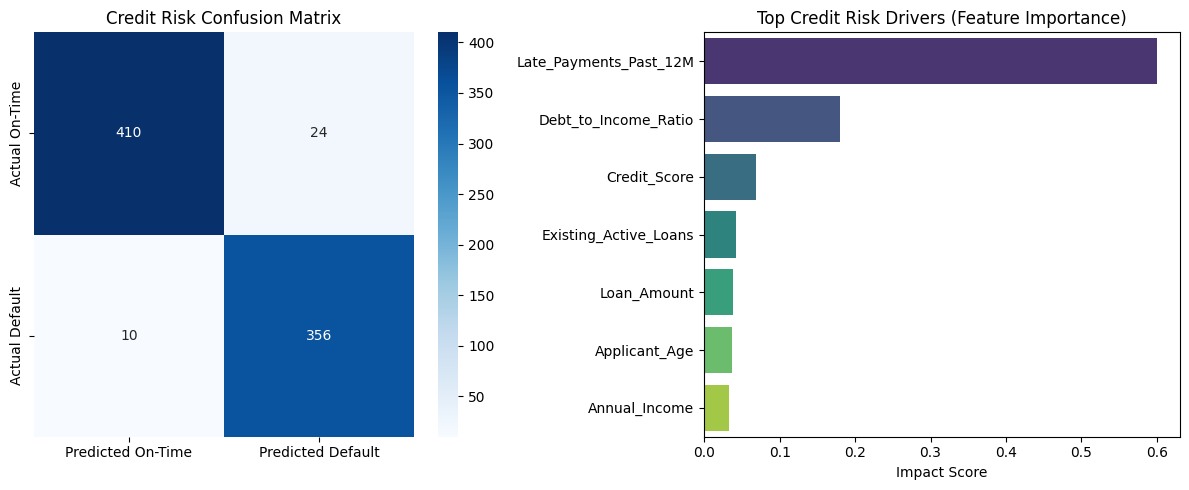


🎯 Model Accuracy: 95.75%
📈 ROC-AUC Score:  0.9904


In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. DATASET GENERATION (Synthesizing Borrower Files)
# ==========================================
np.random.seed(42)
n_samples = 2500

data = {
    'Borrower_ID': [f"BW-{1000+i}" for i in range(n_samples)],
    'Applicant_Age': np.random.randint(21, 65, n_samples),
    'Annual_Income': np.random.randint(150000, 1200000, n_samples),
    'Credit_Score': np.random.randint(300, 850, n_samples),
    'Loan_Amount': np.random.randint(10000, 500000, n_samples),
    'Debt_to_Income_Ratio': np.random.uniform(0.1, 0.65, n_samples),
    'Existing_Active_Loans': np.random.randint(0, 5, n_samples),
    'Late_Payments_Past_12M': np.random.randint(0, 6, n_samples)
}
df = pd.DataFrame(data)

# Underlying Risk Logic
risk_score_raw = (
    (df['Debt_to_Income_Ratio'] * 2.5) +
    (df['Late_Payments_Past_12M'] * 0.6) +
    (df['Existing_Active_Loans'] * 0.2) -
    (df['Credit_Score'] / 900)
)
df['Delinquent_Flag'] = (risk_score_raw > np.percentile(risk_score_raw, 80)).astype(int)

print(f"✅ Microfinance Dataset Ready! Total Records: {len(df)} | Delinquency Cases: {df['Delinquent_Flag'].sum()}")

# ==========================================
# 2. PREPROCESSING & SMOTE CLASS BALANCING
# ==========================================
feature_cols = ['Applicant_Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
                'Debt_to_Income_Ratio', 'Existing_Active_Loans', 'Late_Payments_Past_12M']

X = df[feature_cols]
y = df['Delinquent_Flag']

# Handle severe financial class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# ==========================================
# 3. AI / ML MODEL IMPLEMENTATION
# ==========================================
rf_model = RandomForestClassifier(n_estimators=120, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# ==========================================
# 4. DECISION SUPPORT & REASON CODES (Plain English)
# ==========================================
def generate_risk_assessment(borrower_row):
    features_df = pd.DataFrame([borrower_row], columns=feature_cols)
    prob = rf_model.predict_proba(features_df)[0][1]

    # Risk Tier Assignment
    if prob >= 0.70:
        tier = "HIGH RISK (Manual Intervention Required)"
        action = "Freeze automated disbursement; assign field officer for doorstep audit."
    elif prob >= 0.35:
        tier = "MEDIUM RISK (Review Required)"
        action = "Request collateral/guarantor verification before approval."
    else:
        tier = "LOW RISK (Fast-Track)"
        action = "Approve for automated loan disbursement."

    # Reason Codes (Explainability for Loan Officers)
    reasons = []
    if borrower_row['Late_Payments_Past_12M'] >= 2:
        reasons.append(f"Frequent past late payments ({borrower_row['Late_Payments_Past_12M']} in last 12M)")
    if borrower_row['Debt_to_Income_Ratio'] > 0.45:
        reasons.append(f"High Debt-to-Income ratio ({borrower_row['Debt_to_Income_Ratio']*100:.1f}%)")
    if borrower_row['Credit_Score'] < 580:
        reasons.append(f"Low credit score ({borrower_row['Credit_Score']})")
    if borrower_row['Existing_Active_Loans'] >= 3:
        reasons.append(f"Multiple active obligations ({borrower_row['Existing_Active_Loans']} loans)")
    if not reasons:
        reasons.append("Strong repayment history and balanced debt profile")

    return {
        "Default Probability": f"{prob*100:.1f}%",
        "Risk Tier": tier,
        "Recommended Action": action,
        "Primary Risk Drivers": reasons
    }

# ==========================================
# 5. VALIDATION USING SCENARIO CHECKS
# ==========================================
print("\n" + "="*50)
print("🧪 SCENARIO CHECKS (Test Cases for Decision Support)")
print("="*50)

test_scenarios = [
    {"Name": "High Risk Applicant", "data": [34, 220000, 480, 250000, 0.58, 4, 4]},
    {"Name": "Low Risk Applicant", "data": [45, 850000, 780, 100000, 0.18, 1, 0]}
]

for sc in test_scenarios:
    row_dict = dict(zip(feature_cols, sc["data"]))
    assessment = generate_risk_assessment(row_dict)
    print(f"\n📌 Scenario: {sc['Name']}")
    print(f"   Probability: {assessment['Default Probability']}")
    print(f"   Tier:        {assessment['Risk Tier']}")
    print(f"   Action:      {assessment['Recommended Action']}")
    print(f"   Reason Codes: {', '.join(assessment['Primary Risk Drivers'])}")

# ==========================================
# 6. VISUAL EVALUATION & AUDIT CHARTS
# ==========================================
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted On-Time", "Predicted Default"],
            yticklabels=["Actual On-Time", "Actual Default"])
plt.title("Credit Risk Confusion Matrix")

# Feature Importance
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette='viridis')
plt.title("Top Credit Risk Drivers (Feature Importance)")
plt.xlabel("Impact Score")
plt.tight_layout()

plt.savefig("credit_risk_dashboard.png")
plt.show()

print("\n" + "="*50)
print(f"🎯 Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"📈 ROC-AUC Score:  {roc_auc_score(y_test, y_probs):.4f}")
print("="*50)